# Neural Networks with `scikit-learn`

#### 🎯 Learning Goals

1. Learn how to code and train neural networks in `scikit-learn`, for regression and classification.
2. Get an idea about the role of hyperparameters in the neural network.
___

In this notebook, we will very briefly show you how to use `scikit-learn` to set up a neural network for either classification or regression. **We recommend using `scikit-learn` for your project**, as this follows the same syntax of the other estimators you have seen until now. However, as your Python knowledge grows, you will realize that for neural networks, `scikit-learn` is not used. Instead, you will encounter either [PyTorch](https://pytorch.org/), [TensorFlow](https://www.tensorflow.org/), or [JAX](https://jax.readthedocs.io/en/latest/notebooks/quickstart.html). Those are the three dominant libraries in Python when it comes to deep learning. Unfortunately, they are a bit more complicated and require knowledge of a few somewhat advanced concepts that we have not taught you in this course. For your project, working with a known framework such as `scikit-learn` is more than enough.

Lastly, note that we have not taught you `scikit-learn` because it is easy. It is, without doubt, the dominant package in Python when it comes to machine learning. The three above mentioned packages are simply particularly specialized for deep learning (i.e., neural networks with many layers), they do not offer any other type of machine learning techniques such as decision trees, random forests or clustering algorithms that `scikit-learn` implements.

In [1]:
# Import our standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import StandardScaler

## Classification
___

In this short example, we show how to build a neural network to classify multiple categories (virginica, setosa, and versicolors iris flowers).

In [2]:
# Use the iris dataset
df = pd.read_csv("data/iris.csv")

In [3]:
# Initialize a classifier which we will use to classify the species
# Use three hidden layers, with sizes 32, 64, and 32, ReLU activation functions,
# stochastic gradient descent optimization and a regularization paramater
# (lambda or alpha) of 0.001, batchsizes of 32 and 1000 epochs
nnet = MLPClassifier(hidden_layer_sizes=(32, 64, 32), learning_rate_init=0.003, activation="relu", solver="sgd",
                    alpha=0.001, batch_size=32, max_iter=1000)

In [4]:
# Features of our dataset
X = df[df.columns[1:]]
# Scale the inputs
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Outcome - Categorical
y = df["species"]

In [5]:
# Fit the network
nnet.fit(X, y)

# Make predictions
ypred = nnet.predict(X)

# Count the number of missclassifications
missclassifications = ypred != y

print(f"The network missclassifies {missclassifications.sum()} flowers incorrectly.")

The network missclassifies 2 flowers incorrectly.


#### ➡️ ✏️ Task 1

1. Explain the code to one of your classmates.
2. Compute the classification accuracy for the model above.
3. Compute the confusion matrix. 
   You can use `sklearn.metrics.confusion_matrix`, or code it yourself if you need a small coding warm-up.
   
⚠️ What's the number of rows and columns of the confusion matrix here?


In [6]:
# Your Solution

In [7]:
# Sample Solution

# Accuracy
accuracy = (ypred==y).mean()
display(f'Accuracy: {accuracy}')

from sklearn.metrics import confusion_matrix
labels = np.unique(np.concatenate([y, ypred])) 
cm = confusion_matrix(y, ypred, labels=labels)
cm_df = pd.DataFrame(cm, index=pd.Index(labels, name="True"),
                        columns=pd.Index(labels, name="Pred")) # give column / row names
print(cm_df)



'Accuracy: 0.9866666666666667'

Pred        setosa  versicolor  virginica
True                                     
setosa          50           0          0
versicolor       0          49          1
virginica        0           1         49


In [8]:
# Sample solution: confusion matrix without sklearn function
def confusion_matrix_manual(y_true, y_pred, labels=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.shape != y_pred.shape:
        raise ValueError("Shapes differ")

    # label set and index map
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_idx = {lab: i for i, lab in enumerate(labels)}

    # map to indices
    ti = np.array([label_to_idx[lab] for lab in y_true])
    pi = np.array([label_to_idx[lab] for lab in y_pred])

    # accumulate counts
    k = len(labels)
    cm = np.zeros((k, k), dtype=int)
    np.add.at(cm, (ti, pi), 1) # repeated additions at specific indices

    return pd.DataFrame(cm, index=pd.Index(labels, name="True"),
                           columns=pd.Index(labels, name="Pred"))

cm_df = confusion_matrix_manual(y, ypred, labels = np.unique(np.concatenate([y, ypred])) )
print(cm_df)

Pred        setosa  versicolor  virginica
True                                     
setosa          50           0          0
versicolor       0          49          1
virginica        0           1         49


## Regression
___

In this short example, we show how to build a neural network to predict a continuous variable such as the crop yields.

In [9]:
# Use the US crops dataset
df = pd.read_csv("data/us_crops.csv")

In [10]:
# Initialize a neural network to predict the crop yields given the temperature
# Use three hidden layers, with sizes 32, 64, and 32, ReLU activation functions,
# stochastic gradient descent optimization and a regularization paramater
# (lambda or alpha) of 0.001, batchsizes of 32 and 1000 epochs
nnet = MLPRegressor(hidden_layer_sizes=(32, 64, 32), learning_rate_init=0.003, activation="relu", solver="sgd",
                    alpha=0.001, batch_size=32, max_iter=1000)

In [11]:
# Features of our dataset
X = df[["temp"]]
# Output to predict
y = df["yield"]

# Scale the inputs
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Scale the outputs (we cannot use StandardScaler() on a 1D array)
mu, sigma = y.mean(), y.std() # We will use this to scale back to original values!
y = (y - mu) / sigma

In [12]:
# Fit the network
nnet.fit(X, y)

# Make predictions
ypred = nnet.predict(X)

# Reconstruct outputs and scale predictions
y = y * sigma + mu
ypred = ypred * sigma + mu

# Compute the RMSE and MAE
mse = np.sqrt(np.mean((ypred-y)**2))
mae = np.mean(np.abs(ypred - y))

print(f"The root mean square error is {mse}")
print(f"The mean absolute error is {mae}")

The root mean square error is 197.1544577339726
The mean absolute error is 150.50947070880196


#### ➡️ ✏️ Task 2

1. Compare the code to the classification problem in task 1. Did anything change?
2. Plot the model predictions as a function of x. Add the true datapoints to the same plot.
3. Run a linear regression on the same prediction problem, compute the loss, and add the prediction to the plot from before.
   Which model do you prefer? What could be possible issues with the other model?

In [13]:
# Your solution - 2.

# get x and y for your plot
xmin, xmax = X.min(), X.max() # Min/max values in plotting
xs = np.linspace(X.min(), X.max(), 100) # x grid for plot
# Predict 
ys = np.zeros(len(xs)) # ➡️ ✏️ add prediction of the model

# ➡️ ✏️ Your plot


In [14]:
# Your solution - 3.

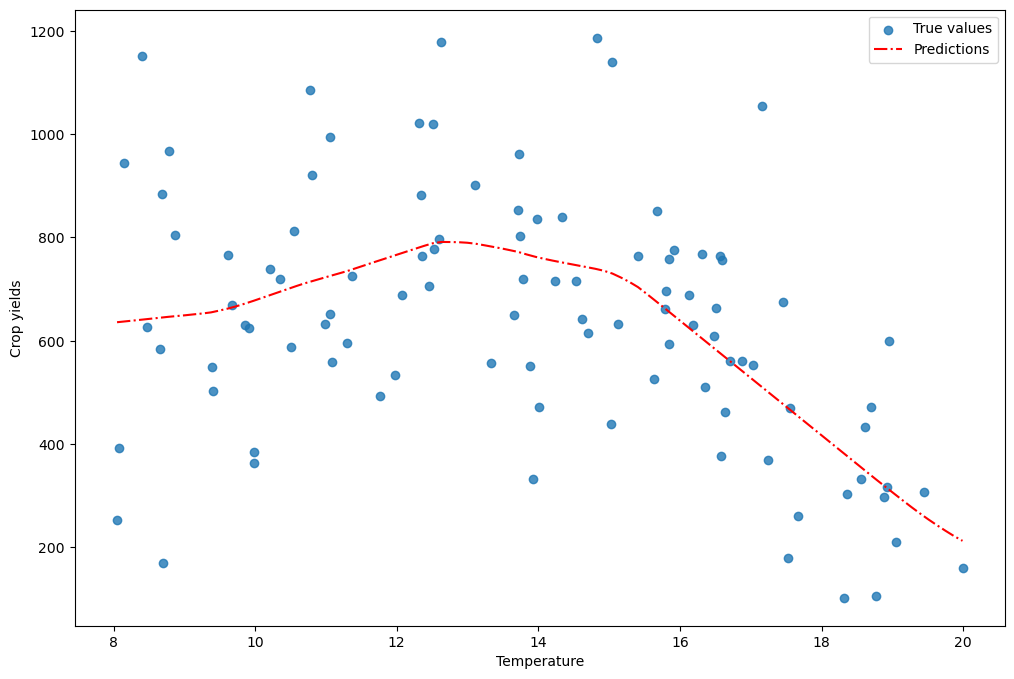

In [15]:
# Sample solution

# get x and y for your plot
xmin, xmax = X.min(), X.max() # Min/max values in plotting
xs = np.linspace(X.min(), X.max(), 100) # spacing
# Predict 
ys = nnet.predict(xs.reshape(-1, 1)) * sigma + mu

# ➡️ ✏️ Your plot
# Plot the results
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the true values
ax.scatter(df["temp"], df["yield"], label="True values", alpha=0.8)
# Plot the predictions
ax.plot(
    scaler.inverse_transform(xs.reshape(-1, 1)),
    ys, color="red", linestyle="dashdot", label="Predictions"
)

# Add labels and legend
ax.set_xlabel("Temperature")
ax.set_ylabel("Crop yields")
ax.legend()

plt.show()

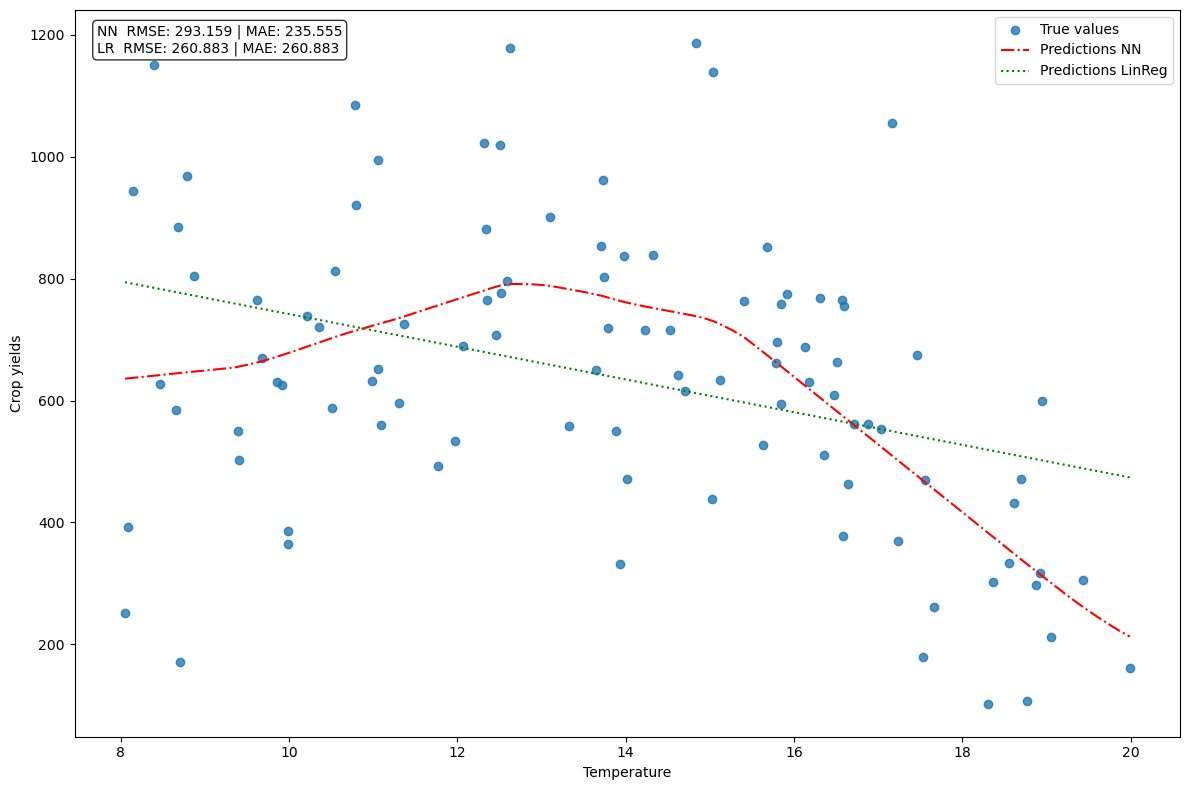

In [16]:
# Plot including linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Compute the beta coefficients using scikit-learn
linreg = LinearRegression(fit_intercept=True)
linreg.fit(X, y)

# get x and y for your plot
xmin, xmax = X.min(), X.max() # Min/max values in plotting
xs = np.linspace(X.min(), X.max(), 100) # spacing
# Predict 
ys_nn = nnet.predict(xs.reshape(-1, 1)) * sigma + mu
ys_linreg = linreg.predict(xs.reshape(-1, 1))

# Compute the RMSE and MAE of both models
rmse_nn, rmse_linreg = [np.sqrt(np.mean((ys_nn-y)**2)) , np.sqrt(np.mean((ys_linreg-y)**2))]
mae_nn, mae_linreg = [np.mean(np.abs(ys_nn - y)), np.sqrt(np.mean((ys_linreg-y)**2))]

# ➡️ ✏️ Your plot
fig, ax = plt.subplots(figsize=(12, 8))

# Data scatter (observed)
ax.scatter(df["temp"], df["yield"], label="True values", alpha=0.8)

# Predictions on original x-scale
x_plot = scaler.inverse_transform(xs.reshape(-1, 1)).ravel()
ax.plot(x_plot, ys_nn, label="Predictions NN", linestyle="-.", color="red")
ax.plot(x_plot, ys_linreg, label="Predictions LinReg", linestyle=":", color="green")  # fix

# Labels and legend
ax.set_xlabel("Temperature")
ax.set_ylabel("Crop yields")
ax.legend()
plt.tight_layout()

# metrics box (original units*)
txt = (f"NN  RMSE: {rmse_nn:.3f} | MAE: {mae_nn:.3f}\n"
       f"LR  RMSE: {rmse_linreg:.3f} | MAE: {mae_linreg:.3f}")
ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.8))

plt.show()

## The network architecture and some hyperparameters
---

In Task 2, we defined our multi-layer perceptron (feed-forward neural network) as:

`MLPRegressor(hidden_layer_sizes=(32, 64, 32), learning_rate_init=0.003, activation="relu", solver="sgd", alpha=0.001, batch_size=32, max_iter=1000)`

The function arguments are called the **hyperparameters** of the neural network.  
These hyperparamters are choices that cannot be optimized within the gradient-based training procedure, but need to be selected beforehand,
similar to the λ in ridge or lasso regression.

Hyperparameters control how the network maps inputs to outputs (x to y), and how the model is estimated (or trained / fitted as machine learning people would say).

Since neural networks are very flexible, appropriate hyperparameter selection is essential for stable training and good out-of-sample performance.


#### Task 3 (optional) ➡️ ✏️
----

1. Go through the hyperparameters one by one and try to understand what they do.  
   Use the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html).

2. How many trainable weights and biases does the model above have?  
   How many parameters (intercept + slope coefficients) does the linear regression from Task 2 have?

3. Experiment: Run the same regression as above, change the hyperparameters one by one,  
   and observe the loss. Which parameters seem important to you?

4. How would you choose the best hyperparameter configuration? Think, and then code your idea for a small grid of hyperparamters.

In [17]:
# Use this function to verify the parameter count from 2.
def count_mlp_params(mlp): return int(sum(W.size + b.size for W, b in zip(mlp.coefs_, mlp.intercepts_)))
mlp = MLPRegressor(hidden_layer_sizes=(32, 64, 32), learning_rate_init=0.003, activation="relu", solver="sgd", alpha=0.001, batch_size=32, max_iter=1000)
X = np.zeros_like(df[["temp"]].to_numpy())
y = np.zeros_like(df["yield"].to_numpy())

count_mlp_params(mlp.fit(X, y)) 
# Remark: The mlp-object alone is not sufficient to count parameters.
# That is because the number of input features is not defined in the MLPRegressor step, but only when the data is added in the .fit call.

4289

In [18]:
# parameter count by hand:
# Example: NN with 1 input feature, 1 output, 3 hidden layers with $n_1,n_2,n_3$ number of neurons:
n_x = 1
n_1 = 32
n_2 = 64
n_3 = 32
n_y = 1

n_weights = n_x * n_1 + n_1 * n_2 + n_2 * n_3 + n_3 * n_y 
n_biases = n_1 + n_2 + n_3 + n_y # 1 intercept per neuron
n_weights + n_biases

4289

In [19]:
# Your Solution - 3.

In [20]:
# Sample solution 3.

# Task 3/4
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Data ---
X_raw = df[["temp"]].to_numpy()
y_raw = df["yield"].to_numpy()

# --- Split ---
# Test loss to evaluate models -> select model (hyperparameters) with best test error
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=0)

# --- Scaling (fit on train only) ---
xsc = StandardScaler().fit(X_tr)
X_tr_s = xsc.transform(X_tr)
X_te_s = xsc.transform(X_te)

mu_tr, sigma_tr = y_tr.mean(), y_tr.std()
y_tr_s = (y_tr - mu_tr) / sigma_tr

# --- Helpers ---
def rmse(y, yhat): return float(np.sqrt(np.mean((yhat - y)**2)))
def mae(y, yhat):  return float(np.mean(np.abs(yhat - y)))
def count_mlp_params(mlp): return int(sum(W.size + b.size for W, b in zip(mlp.coefs_, mlp.intercepts_)))
def count_linreg_params(d): return int(d + 1)

# --- Baseline: Linear Regression (same split, same scaling convention for y) ---
lr = LinearRegression().fit(X_tr_s, y_tr_s)
yhat_lr_te = lr.predict(X_te_s) * sigma_tr + mu_tr
baseline = {"model":"LinReg", "hidden_layer_sizes":None, "activation":None, "solver":None,
            "alpha":None, "lr_init":None, "n_params":count_linreg_params(X_raw.shape[1]),
            "rmse_test":rmse(y_te, yhat_lr_te), "mae_test":mae(y_te, yhat_lr_te)}

# --- Task 3: small grid, train on train, evaluate on test ---
# Note: the size of the grid determines how many times you run the model -> controls the runtime.
grid = {
    "hidden_layer_sizes": [(16,), (32,), (32,32)],
    "activation": ["relu"], # , "tanh"
    "solver": ["sgd"], # "adam", 
    "alpha": [1e-4, 1e-3],
    "learning_rate_init": [1e-3, 3e-3],
    "batch_size": [32],
    "max_iter": [1000],
    "random_state": [0],
}

rows = [baseline]
keys, vals = zip(*grid.items())
for combo in product(*vals):
    params = dict(zip(keys, combo))
    mlp = MLPRegressor(**params).fit(X_tr_s, y_tr_s)
    yhat_te = mlp.predict(X_te_s) * sigma_tr + mu_tr
    rows.append({
        "model":"MLP",
        "hidden_layer_sizes":params["hidden_layer_sizes"],
        "activation":params["activation"],
        "solver":params["solver"],
        "alpha":params["alpha"],
        "lr_init":params["learning_rate_init"],
        "n_params":count_mlp_params(mlp),
        "rmse_test":rmse(y_te, yhat_te),
        "mae_test":mae(y_te, yhat_te),
    })

res = pd.DataFrame(rows).sort_values("rmse_test").reset_index(drop=True)
print("# Train/Test results (sorted by RMSE on test)")
print(res.head(10))

best = res.iloc[0]
print("\nBest Model on by test RMSE:")
print(best)


# Train/Test results (sorted by RMSE on test)
  model hidden_layer_sizes activation solver   alpha  lr_init  n_params  \
0   MLP           (32, 32)       relu    sgd  0.0001    0.003      1153   
1   MLP           (32, 32)       relu    sgd  0.0010    0.003      1153   
2   MLP              (32,)       relu    sgd  0.0001    0.003        97   
3   MLP              (32,)       relu    sgd  0.0010    0.003        97   
4   MLP              (16,)       relu    sgd  0.0001    0.003        49   
5   MLP              (16,)       relu    sgd  0.0010    0.003        49   
6   MLP              (32,)       relu    sgd  0.0001    0.001        97   
7   MLP              (32,)       relu    sgd  0.0010    0.001        97   
8   MLP           (32, 32)       relu    sgd  0.0001    0.001      1153   
9   MLP           (32, 32)       relu    sgd  0.0010    0.001      1153   

    rmse_test    mae_test  
0  146.660044  111.611108  
1  146.695783  111.648113  
2  148.465227  112.906315  
3  148.483666  1

## ⚠️ A final word of caution
----
Neural networks are very flexible and can perform well if used  in the right setting and handled correctly.

But neural networks are not the *end-all be-all* of machine learning models. They come with many hyperparameters, and choosing the right ones is a daunting task. As you might have found out, a change in hyperparameters can lead to drastic changes in the model (good or bad).

Due to their flexibility, neural networks are prone to overfitting if not controlled accordingly. If your network is very unstable, a good performance might simply mean that you had a lucky seed on your validation set. Be wary.

In this notebook, we have chosen some hyperparameters that might be good or bad. Do not just use the ones from these examples; try to find the best ones for your problem instead (*Hint*: think about some methods we have seen to determine which model is best). Furthermore, scaling is incredibly important. If you try running the regression problem without scaling the output, you will see that the network performs much worse than even the simplest estimator we covered in class.
